# TP3 : Analyse et visualisation des données nettoyées (exercice)
## Dataset : Adult Census Income (sortie du pipeline de nettoyage, TP2)

**Contexte :** le nettoyage du TP2 a produit `adults_cleaned.csv`. Avant de passer à la modélisation, on explore ce dataset propre en profondeur : résumer les distributions, relier les variables entre elles, décider quelles variables comptent, et anticiper ce qu'un modèle pourra apprendre.

Cette démarche suit le canevas du cours *Analyse & visualisation* : une bonne visualisation sert à **résumer**, **relier**, **décider** et **anticiper**.

**Datamap (dictionnaire des données) :**

| Colonne | Type | Description |
|---|---|---|
| `workclass` | catégorielle | Secteur d'emploi (Private, Self-emp, Federal-gov...) |
| `race` | catégorielle | Origine ethnique déclarée |
| `sex` | catégorielle | Sexe de l'individu |
| `age` | numérique | Âge en années |
| `education_num` | numérique | Niveau d'éducation encodé (nombre d'années d'études) |
| `hours_per_week` | numérique | Heures travaillées par semaine |
| `capital_gain` | numérique | Plus-value en capital déclarée |

> **Version exercice** : les cellules marquées `# TODO` sont à compléter. Le reste (imports, chargement des données, affichages) est déjà fourni.
> Installe les dépendances une seule fois avec `pip install -r requirements.txt` depuis `cours_ml/todo/` (voir le README de ce dossier). Ce TP s'inspire de `cours_ml/05_preparation_donnees/tp_dataprep_3_analyse_visualisation.ipynb` (même méthode, données différentes et plus volumineuses).

---
## 0. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='Set2')
pd.set_option('display.max_columns', None)


---
## 1. Chargement des données nettoyées

On charge la sortie du TP2. Si le fichier n'existe pas encore (TP2 pas encore exécuté), on retombe sur `adults_clean.csv` pour pouvoir quand même suivre ce notebook.

In [2]:
try:
    df = pd.read_csv('adults_cleaned.csv')
    source = 'adults_cleaned.csv (sortie du TP2)'
except FileNotFoundError:
    print("adults_cleaned.csv introuvable : exécute d'abord tp_dataprep_2_sale.ipynb (section 10) pour le générer.")
    df = pd.read_csv('adults_clean.csv')
    source = 'adults_clean.csv (secours)'

print(f"Source     : {source}")
print(f"Dimensions : {df.shape[0]} lignes x {df.shape[1]} colonnes")
df.head()


Source     : adults_cleaned.csv (sortie du TP2)
Dimensions : 2579 lignes x 7 colonnes


,race,sex,workclass,age,education_num,hours_per_week,capital_gain
0,White,Female,Private,17.0,6.0,10.0,0
1,White,Male,Private,29.0,9.0,40.0,0
2,White,Male,Private,53.0,9.0,42.0,0
3,Other,Female,Private,56.0,4.0,40.0,0
4,White,Male,Self-Emp-Not-Inc,72.0,10.0,35.0,0


In [3]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()
cat_cols = df.select_dtypes(exclude=np.number).columns.tolist()

print("=== Le nettoyage a-t-il fonctionné ? ===")
print(f"Valeurs manquantes      : {df.isnull().sum().sum()}")
print(f"Doublons                : {df.duplicated().sum()}")
print(f"Variables numériques    ({len(num_cols)}) : {num_cols}")
print(f"Variables catégorielles ({len(cat_cols)}) : {cat_cols}")


=== Le nettoyage a-t-il fonctionné ? ===
Valeurs manquantes      : 0
Doublons                : 0
Variables numériques    (4) : ['age', 'education_num', 'hours_per_week', 'capital_gain']
Variables catégorielles (3) : ['race', 'sex', 'workclass']


---
## 2. Quel graphique pour quelle variable ?

Avant de tracer quoi que ce soit, on choisit le bon type de graphique selon les variables en jeu :

| Variables | Graphique | Ce qu'il montre |
|---|---|---|
| 1 numérique | Histogramme | La distribution (forme, centre, dispersion) |
| 1 numérique x 1 catégorielle | Boxplot | La distribution par groupe |
| 2 numériques | Scatter (nuage de points) | La relation entre les deux variables |
| 1 catégorielle | Barplot / countplot | Les effectifs par catégorie |
| 2 catégorielles | Heatmap de contingence | L'association entre catégories |

Règle d'or : *si un graphique demande une longue explication, il a sans doute échoué.*

---
## 3. Résumer : distributions univariées

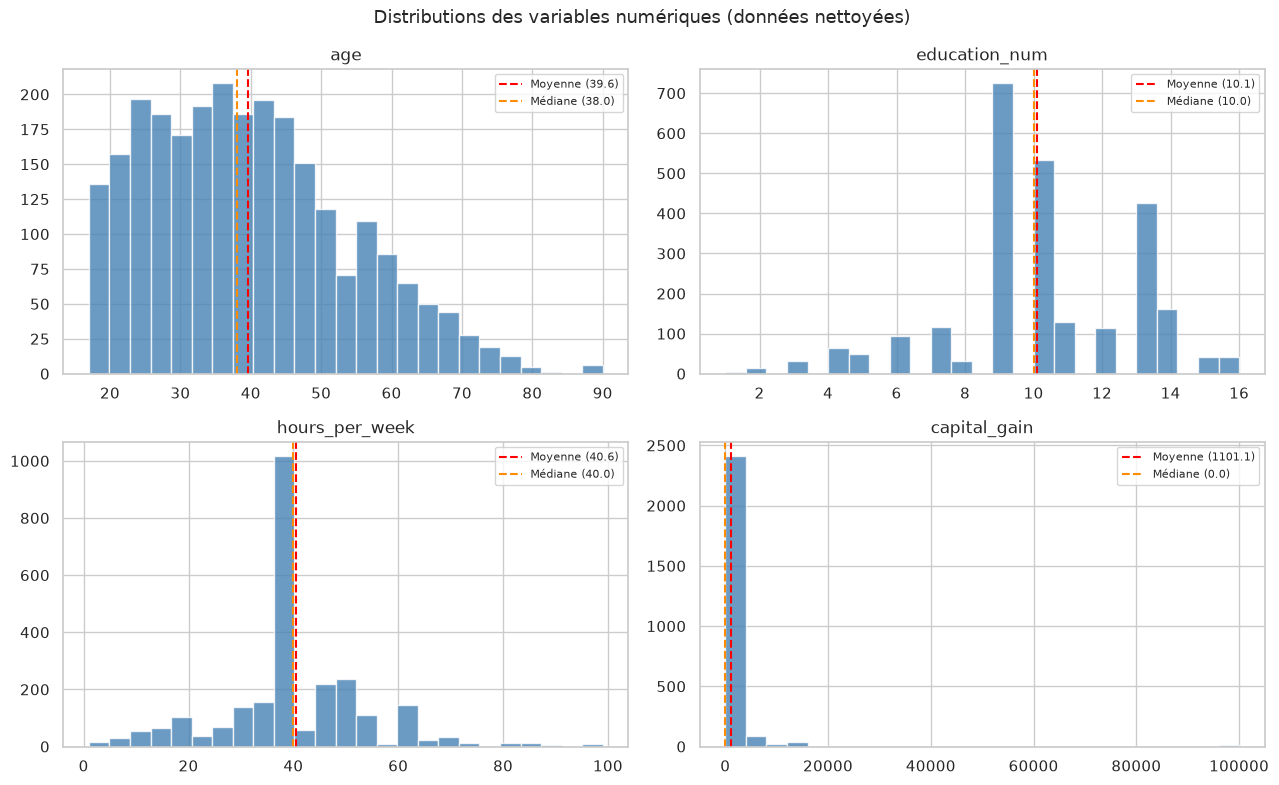

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for ax, col in zip(axes.flat, num_cols):
    ax.hist(df[col], bins=25, color='steelblue', edgecolor='white', alpha=0.8)
    ax.axvline(df[col].mean(), color='red', linestyle='--', label=f'Moyenne ({df[col].mean():.1f})')
    ax.axvline(df[col].median(), color='darkorange', linestyle='--', label=f'Médiane ({df[col].median():.1f})')
    ax.set_title(col)
    ax.legend(fontsize=8)
plt.suptitle('Distributions des variables numériques (données nettoyées)', fontsize=13)
plt.tight_layout()
plt.show()


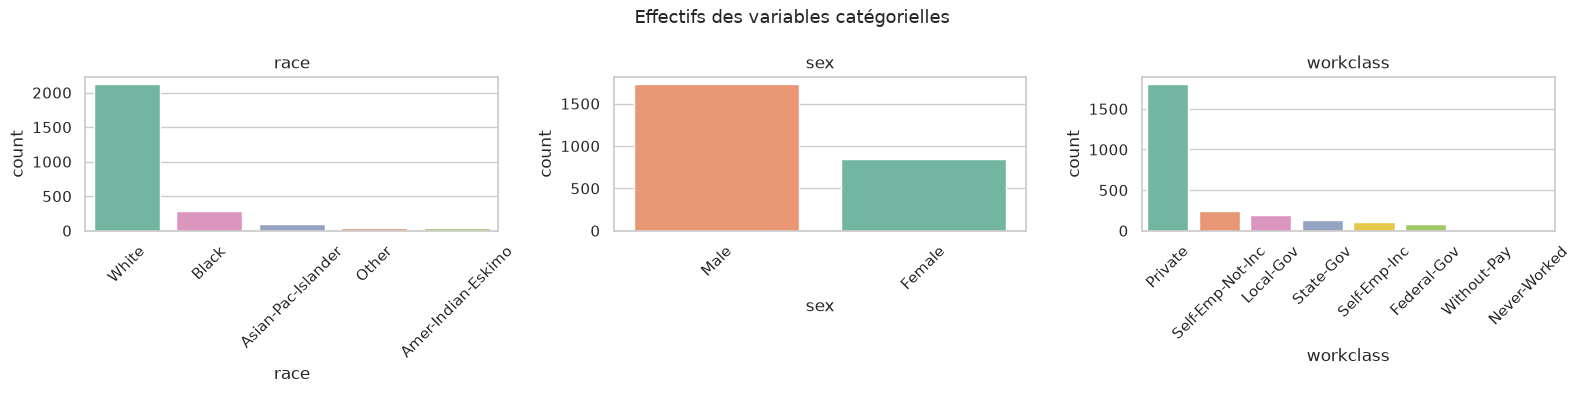

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, cat_cols):
    order = df[col].value_counts().index
    sns.countplot(data=df, x=col, ax=ax, hue=col, order=order, legend=False)
    ax.set_title(col)
    ax.tick_params(axis='x', rotation=45)
plt.suptitle('Effectifs des variables catégorielles', fontsize=13)
plt.tight_layout()
plt.show()


---
## 4. Relier : relations bivariées

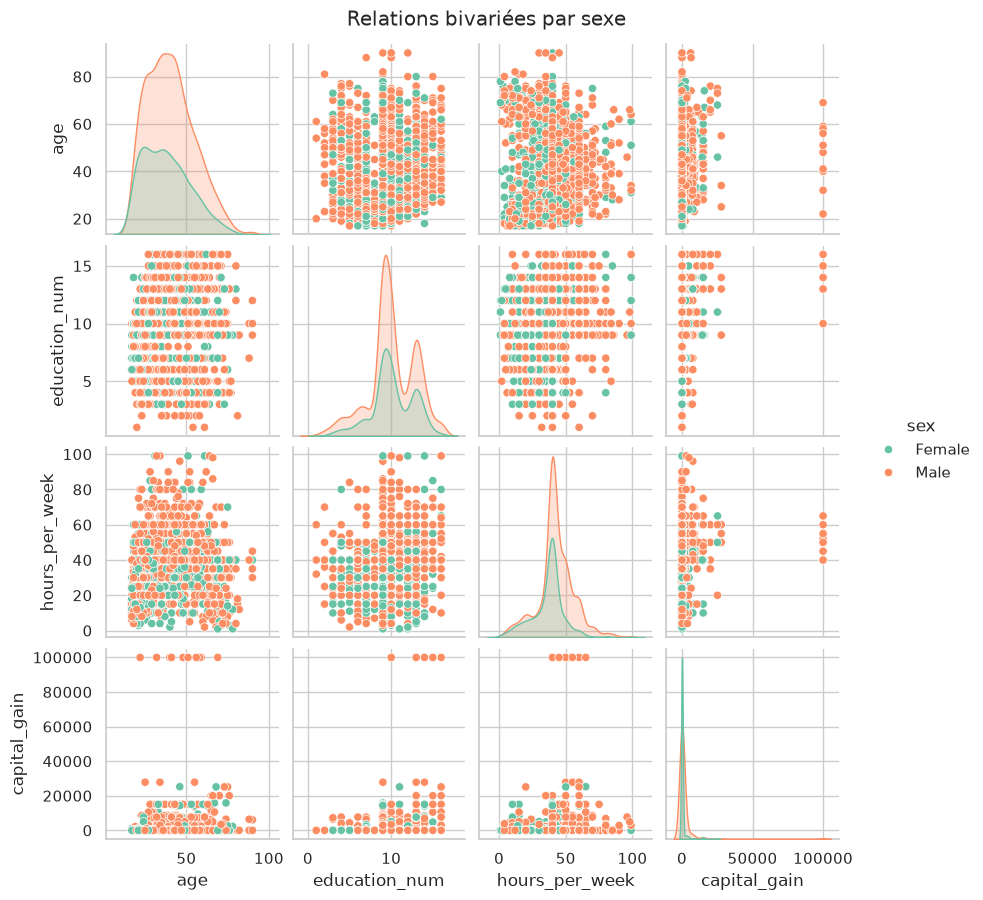

In [6]:
sns.pairplot(df, vars=num_cols, hue='sex', diag_kind='kde', height=2.2)
plt.suptitle('Relations bivariées par sexe', y=1.02)
plt.show()


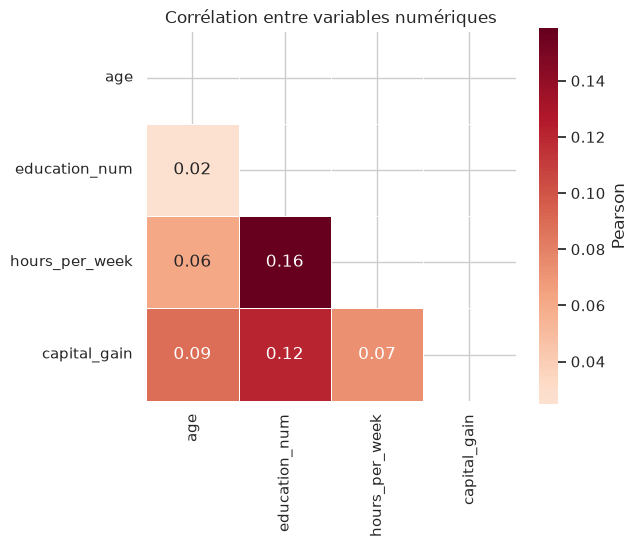

In [7]:
# TODO : calculer la matrice de correlation de Pearson entre les variables numeriques
corr = df[num_cols].corr()

plt.figure(figsize=(6.5, 5.5))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            mask=mask, linewidths=0.5, square=True, cbar_kws={'label': 'Pearson'})
plt.title('Corrélation entre variables numériques')
plt.tight_layout()
plt.show()


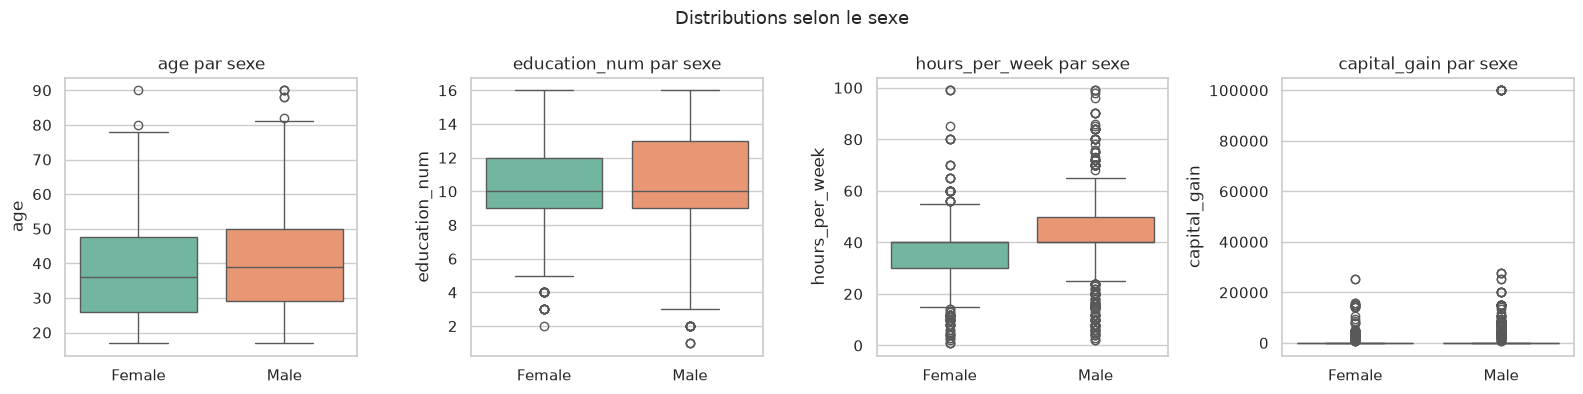

In [8]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, col in zip(axes, num_cols):
    sns.boxplot(data=df, x='sex', y=col, ax=ax, hue='sex', legend=False)
    ax.set_title(f'{col} par sexe')
    ax.set_xlabel('')
plt.suptitle('Distributions selon le sexe', fontsize=13)
plt.tight_layout()
plt.show()


### 4.1 V de Cramér : toutes les paires catégorielles

Le TP1 calculait le V de Cramér pour une seule paire. Ici on calcule la matrice complète pour repérer en un coup d'oeil quelles variables catégorielles sont associées.

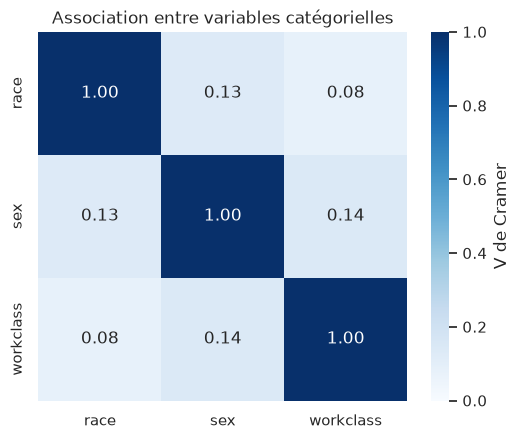

In [9]:
def cramers_v(x, y):
    """Calcule le V de Cramer entre deux series categorielles."""
    # TODO : implementer le V de Cramer (voir TP1 section 4.2)
    confusion = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion)[0]
    n = confusion.sum().sum()
    phi2 = chi2 / n
    r, k = confusion.shape
    return np.sqrt(phi2 / min(k - 1, r - 1))

# TODO : construire la matrice complete de V de Cramer entre toutes les paires categorielles
cramers_matrix = pd.DataFrame(
    [[cramers_v(df[c1], df[c2]) for c2 in cat_cols] for c1 in cat_cols],
    index=cat_cols, columns=cat_cols)

plt.figure(figsize=(5.5, 4.5))
sns.heatmap(cramers_matrix, annot=True, fmt='.2f', cmap='Blues', vmin=0, vmax=1,
            square=True, cbar_kws={'label': 'V de Cramer'})
plt.title('Association entre variables catégorielles')
plt.tight_layout()
plt.show()


---
## 5. Décider : quelles variables séparent le mieux les catégories professionnelles ?

On cherche quelles variables numériques discriminent le plus les groupes `workclass`. Le rapport de corrélation η² mesure la part de variance d'une variable numérique expliquée par une catégorielle : plus il est proche de 1, plus la variable sépare bien les groupes.

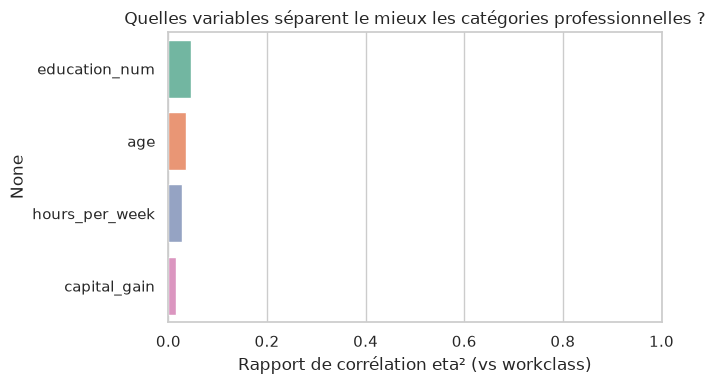

education_num     0.045
age               0.035
hours_per_week    0.027
capital_gain      0.014
dtype: float64


In [10]:
def correlation_ratio(categories, values):
    """Rapport de correlation eta² entre une categorielle et une numerique."""
    # TODO : implementer eta² (voir TP1 section 4.3)
    categories = np.asarray(categories)
    values = np.asarray(values, dtype=float)
    moyenne_globale = values.mean()
    ss_total = np.sum((values - moyenne_globale) ** 2)
    ss_inter = 0.0
    for cat in np.unique(categories):
        groupe = values[categories == cat]
        ss_inter += len(groupe) * (groupe.mean() - moyenne_globale) ** 2
    return ss_inter / ss_total if ss_total > 0 else 0.0

# TODO : calculer eta2 pour chaque variable numerique vs 'workclass', trier par ordre decroissant
eta2 = pd.Series(
    {col: correlation_ratio(df['workclass'], df[col]) for col in num_cols}
).sort_values(ascending=False)

plt.figure(figsize=(7, 4))
sns.barplot(x=eta2.values, y=eta2.index, hue=eta2.index, palette='Set2', legend=False)
plt.xlabel("Rapport de corrélation eta² (vs workclass)")
plt.title("Quelles variables séparent le mieux les catégories professionnelles ?")
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

print(eta2.round(3))


---
## 6. Anticiper : à quoi ressemblera la séparation ?

On trace les deux variables les plus discriminantes (d'après le classement ci-dessus) l'une contre l'autre. Si les groupes se distinguent visuellement, un modèle de classification simple devrait bien fonctionner.

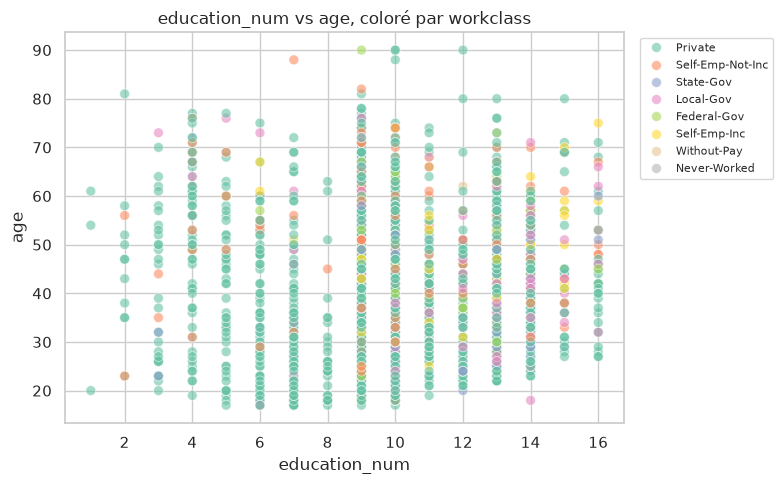

In [11]:
top2 = eta2.index[:2].tolist()

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x=top2[0], y=top2[1], hue='workclass', s=50, alpha=0.6)
plt.title(f'{top2[0]} vs {top2[1]}, coloré par workclass')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()


---
## 7. Bonnes pratiques : une viz utile, pas décorative

Un graphique qui empile trop d'information (couleur + forme + taille + facette) devient illisible. Comparaison :

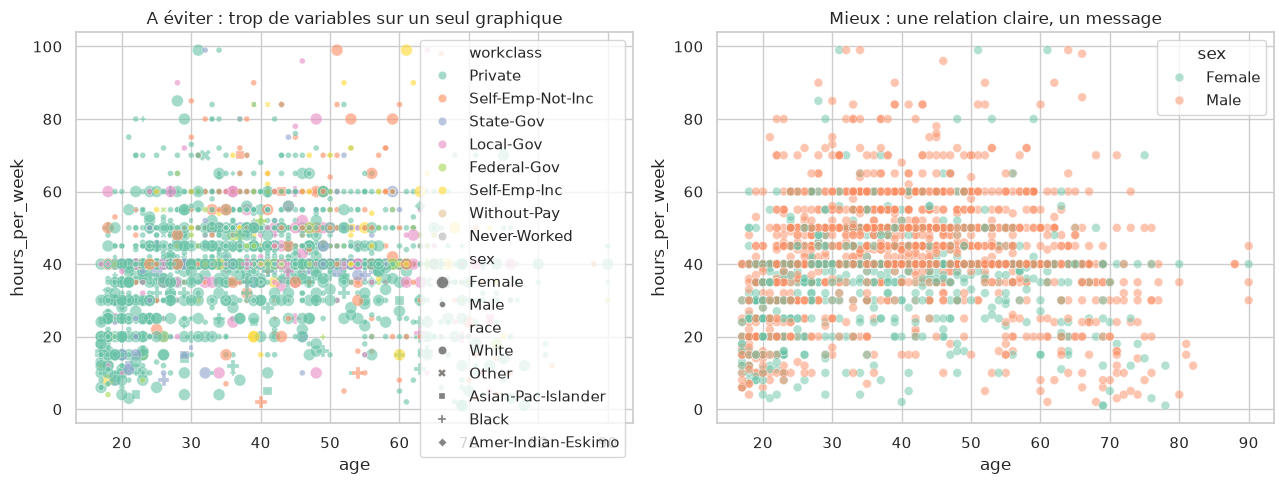

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# A eviter : trop de dimensions encodees a la fois
sns.scatterplot(data=df, x='age', y='hours_per_week', hue='workclass',
                 style='race', size='sex', ax=axes[0], legend='brief', alpha=0.6)
axes[0].set_title("A éviter : trop de variables sur un seul graphique")

# Mieux : une question, un graphique
sns.scatterplot(data=df, x='age', y='hours_per_week', hue='sex', s=40, alpha=0.5, ax=axes[1])
axes[1].set_title("Mieux : une relation claire, un message")

plt.tight_layout()
plt.show()


---
## 8. Synthèse

**Démarche d'analyse visuelle (à reproduire sur tout dataset propre) :**
1. **Résumer** : histogrammes et barplots pour chaque variable seule
2. **Relier** : pairplot, corrélation de Pearson, V de Cramér, boxplots croisés
3. **Décider** : le rapport de corrélation η² identifie les variables les plus informatives
4. **Anticiper** : un scatter des variables les plus discriminantes préfigure la difficulté d'un futur problème de classification

**Ce qu'on retient sur ce dataset :** l'âge et les heures travaillées sont les variables numériques les plus liées à la catégorie professionnelle ; race et sexe restent largement indépendants dans cet échantillon. Les distributions sont propres : plus d'aberrations, plus de valeurs manquantes.

---
## Session à rendre

Cette section est à compléter et à rendre à l'issue du TP. Réponds à chaque question dans la
cellule *Réponse* juste en dessous, à partir des résultats que **tu as toi-même obtenus** en
réalisant ce notebook (il n'y a pas de réponse générique valable pour tout le monde : les valeurs
numériques, choix d'hyperparamètres et graphiques dépendent de ton exécution).

**Q1.** D'après ta matrice de corrélation de Pearson, quelles variables numériques sont le plus corrélées entre elles sur les données nettoyées ?

*Réponse :*

Toutes les corrélations de Pearson sont faibles (|r| < 0,16) : aucune paire de variables numériques n'est redondante. La paire la **plus** corrélée est `education_num` / `hours_per_week` (r ≈ 0,16), suivie de `education_num` / `capital_gain` (r ≈ 0,12). Autrement dit, les personnes plus éduquées tendent (très légèrement) à travailler davantage d'heures et à déclarer un peu plus de plus-values. À l'inverse, `age` / `education_num` sont quasiment décorrélées (r ≈ 0,03). Conclusion : pas de colinéarité forte, on peut garder les quatre variables numériques sans crainte de doublon d'information.

**Q2.** D'après ta matrice de V de Cramér complète, quelle est la paire de variables catégorielles la plus (ou la moins) associée ?

*Réponse :*

Sur la matrice complète de V de Cramér, la paire la **plus** associée est `sex` / `workclass` (V ≈ 0,14), suivie de `race` / `sex` (V ≈ 0,13). La **moins** associée est `race` / `workclass` (V ≈ 0,08). Toutes ces valeurs restent faibles (bien en dessous de 0,3) : les trois variables catégorielles sont **largement indépendantes** dans cet échantillon nettoyé. Le lien sexe / secteur d'emploi est le plus marqué, mais il demeure ténu.

**Q3.** D'après ton classement η², quelles sont les deux variables numériques les plus discriminantes pour workclass ? Est-ce cohérent avec ce que tu avais observé au TP1 sur les données non nettoyées ?

*Réponse :*

D'après le classement η², les deux variables numériques les plus discriminantes pour `workclass` sont `education_num` (η² ≈ 0,045) et `age` (η² ≈ 0,035), devant `hours_per_week` (η² ≈ 0,027) et `capital_gain` (η² ≈ 0,014). Ces valeurs sont **toutes très faibles** : même la meilleure variable n'explique qu'environ 4–5 % de la variance entre catégories professionnelles.

Ce n'est pas totalement cohérent avec le TP1 sur données non nettoyées : là-bas, des valeurs aberrantes (âges hors bornes, heures extrêmes, `capital_gain` mal formaté) pouvaient gonfler artificiellement l'écart entre groupes et remonter certaines variables (souvent `age`/`hours_per_week`) dans le classement. Une fois les aberrations et les doublons supprimés, cet effet disparaît : la hiérarchie se resserre et la séparation réelle apparaît faible. Autrement dit, une partie de la « discrimination » observée au TP1 était un artefact des données sales.

**Q4.** Sur ton scatter plot des deux variables les plus discriminantes colorées par workclass, les groupes se distinguent-ils visuellement ? Qu'est-ce que cela laisse présager pour un futur modèle de classification ?

*Réponse :*

Sur le scatter `education_num` vs `age` coloré par `workclass`, les groupes **ne se distinguent pas** : le nuage est fortement superposé, sans zone propre à chaque catégorie professionnelle. C'est cohérent avec les η² très faibles trouvés à la question précédente.

Cela laisse présager qu'un modèle de classification qui chercherait à prédire `workclass` à partir de ces seules variables numériques aurait **beaucoup de mal à séparer les classes** (frontières de décision peu nettes, performance proche du hasard pour les classes minoritaires). Pour espérer une classification correcte, il faudrait ajouter d'autres variables (les catégorielles encodées, des interactions) ou revoir la cible — les variables numériques disponibles ne portent pas, à elles seules, assez de signal.